# Thesis Work - April 4 - Recyclable vs Non-Recyclable Model - NEW
## Recyclable/Non-Recyclable DenseNet121 Model trained on a more realistic dataset obtained from GitHub

## Importing Necessary Libraries

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Clone the GitHub Dataset

In [ ]:
# The dataset lives directly in the GitHub repo
# GitHub truncates to 1000 files per folder when viewing online, but cloning gives the full dataset (~34,000 images)

REPO_DIR = "/content/BinaryClassification-Recyclables-and-non-Recyclables-"

if not os.path.exists(REPO_DIR):
    os.system("git clone https://github.com/chrisfejiro/BinaryClassification-Recyclables-and-non-Recyclables-.git /content/BinaryClassification-Recyclables-and-non-Recyclables-")

DATASET_DIR = Path(REPO_DIR) / "DatasetFinal"

print("Dataset dir exists:", DATASET_DIR.exists())
print("Contents:", os.listdir(DATASET_DIR))

# Count images per class
for cls in os.listdir(DATASET_DIR):
    cls_path = DATASET_DIR / cls
    if cls_path.is_dir():
        n = len([f for f in cls_path.iterdir() if f.is_file()])
        print(f"  {cls}: {n} images")

Dataset dir exists: True
Contents: ['Recyclables', 'Non-Recyclables']
  Recyclables: 17677 images
  Non-Recyclables: 16782 images


## Split into Train / Validation / Test

In [ ]:
SPLIT_ROOT = Path("/content/recyclable_v2_split")
train_out = SPLIT_ROOT / "train"
val_out   = SPLIT_ROOT / "val"
test_out  = SPLIT_ROOT / "test"

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Only rebuild if not already done
if not SPLIT_ROOT.exists():
    # Collect all images and labels
    data = []
    for cls_folder in os.listdir(DATASET_DIR):
        cls_path = DATASET_DIR / cls_folder
        if not cls_path.is_dir():
            continue
        # Normalise folder name → binary label
        if "non" in cls_folder.lower():
            label = "non_recyclable"
        else:
            label = "recyclable"
        for f in cls_path.iterdir():
            if f.is_file() and f.suffix.lower() in img_exts:
                data.append((str(f), label))

    df_all = pd.DataFrame(data, columns=["filepath", "label"])
    print("\nFull dataset distribution:")
    print(df_all["label"].value_counts())

    # Stratified split: 70% train, 15% val, 15% test
    train_df, temp_df = train_test_split(
        df_all, test_size=0.30, stratify=df_all["label"], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
    )

    print(f"\nSplit sizes — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    # Copy files into split folders
    def copy_split(split_df, split_dir):
        for label in split_df["label"].unique():
            (split_dir / label).mkdir(parents=True, exist_ok=True)
        for _, row in split_df.iterrows():
            src = Path(row["filepath"])
            dst = split_dir / row["label"] / src.name
            shutil.copy2(src, dst)

    copy_split(train_df, train_out)
    copy_split(val_df,   val_out)
    copy_split(test_df,  test_out)
    print("Split complete.")
else:
    print("Split already exists, skipping.")


Full dataset distribution:
label
recyclable        17677
non_recyclable    16782
Name: count, dtype: int64

Split sizes — Train: 24121 | Val: 5169 | Test: 5169
Split complete.


## Adding Generators

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_out,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=True
)

val_gen = eval_datagen.flow_from_directory(
    val_out,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    test_out,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
# Should be: {'non_recyclable': 0, 'recyclable': 1}

Found 24121 images belonging to 2 classes.
Found 5169 images belonging to 2 classes.
Found 5169 images belonging to 2 classes.
Class indices: {'non_recyclable': 0, 'recyclable': 1}


## Computing Class Weights

In [ ]:
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0266876649357282), 1: np.float64(0.9746646193631808)}


## Building + Training DenseNet121 Model

In [ ]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(256, activation="relu")(x)
x       = Dropout(0.5)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Training Phase (Frozen Base)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.3)
]

print("\n=== PHASE 1: Feature Extraction ===")
history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)

best_p1_train = max(history_p1.history["accuracy"])
best_p1_val   = max(history_p1.history["val_accuracy"])
print(f"\nPhase 1 — Best Train: {best_p1_train:.4f} | Best Val: {best_p1_val:.4f}")

# Fine-Tuning Phase
for layer in base_model.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\n=== PHASE 2: Fine-Tuning ===")
history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)

best_p2_train = max(history_p2.history["accuracy"])
best_p2_val   = max(history_p2.history["val_accuracy"])
print(f"\nPhase 2 — Best Train: {best_p2_train:.4f} | Best Val: {best_p2_val:.4f}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)


=== PHASE 1: Feature Extraction ===
Epoch 1/5
754/754 ━━━━━━━━━━━━━━━━━━━━ 444s 549ms/step - accuracy: 0.8911 - loss: 0.2584 - val_accuracy: 0.9402 - val_loss: 0.1508 - learning_rate: 1.0000e-04
Epoch 2/5
754/754 ━━━━━━━━━━━━━━━━━━━━ 372s 493ms/step - accuracy: 0.9374 - loss: 0.1603 - val_accuracy: 0.9493 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 3/5
754/754 ━━━━━━━━━━━━━━━━━━━━ 373s 495ms/step - accuracy: 0.9484 - loss: 0.1378 - val_accuracy: 0.9551 - val_loss: 0.1134 - learning_rate: 1.0000e-04
Epoch 4/5
754/754 ━━━━━━━━━━━━━━━━━━━━ 376s 498ms/step - accuracy: 0.9547 - loss: 0.1259 - val_accuracy: 0.9584 - val_loss: 0.1057 - learning_rate: 1.0000e-04
Epoch 5/5
754/754 ━━━━━━━━━━━━━━━━━━━━ 373s 494ms/step - accuracy: 0.9574 - loss: 0.1150 - val_accuracy: 0.9598 - val_loss: 0.1039 - learning_rate: 1.0000e-04

Phase 1 — Best Train: 0.9574 | Best Val: 0.9598

=== PHASE 2: Fine-Tuning ===
Epoch 1/5
754/754 ━━━━━━━━━━━━━━━━━━━━ 463s 558ms/step - accuracy: 0.9487 - loss: 0.1322 

## Evaluation on Test Set

162/162 ━━━━━━━━━━━━━━━━━━━━ 43s 187ms/step

=== TEST SET RESULTS ===
                precision    recall  f1-score   support

non_recyclable       0.98      0.96      0.97      2518
    recyclable       0.96      0.98      0.97      2651

      accuracy                           0.97      5169
     macro avg       0.97      0.97      0.97      5169
  weighted avg       0.97      0.97      0.97      5169



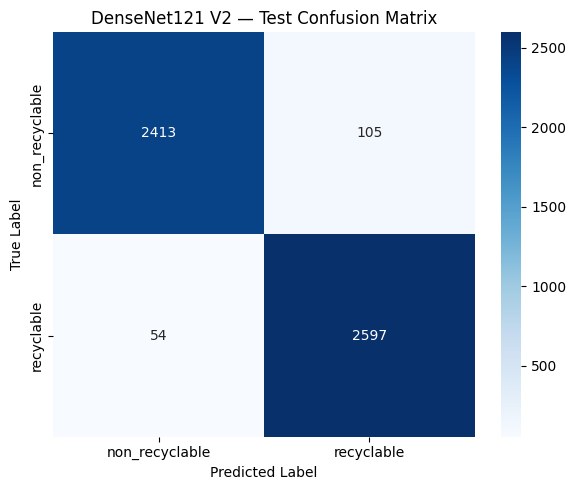

In [ ]:
test_gen.reset()
test_probs = model.predict(test_gen)
test_preds = (test_probs > 0.5).astype(int).flatten()
test_true  = test_gen.classes

class_names = ["non_recyclable", "recyclable"]

print("\n=== TEST SET RESULTS ===")
print(classification_report(test_true, test_preds, target_names=class_names))

cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("DenseNet121 V2 — Test Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Saving the Model

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/Thesis_Models/DenseNet121_binary_v2.keras"
model.save(SAVE_PATH)
print("Model saved to:", SAVE_PATH)

Model saved to: /content/drive/MyDrive/Thesis_Models/DenseNet121_binary_v2.keras
